## **Multiclass Classification**
DOMANDA: is the type of mutation in TP53 affecting the RNA sequencing or not?

## Clara ha usato anche queste colonne:
**Sift, Polyphen, VepImpact, VariantInfo**

## **Data Loading**

In [99]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [100]:
mutation = pd.read_csv('OmicsSomaticMutations.csv')
mutation = mutation[mutation.HugoSymbol == 'TP53'] # filter for TP53 mutations


/var/folders/r9/tk3nsgjj4_j4z3n_rxsd7s580000gn/T/ipykernel_94516/1288859853.py:1: DtypeWarning: Columns (22,50,56,57,58,59,61) have mixed types. Specify dtype option on import or set low_memory=False.
  mutation = pd.read_csv('OmicsSomaticMutations.csv')


## **Analysis on column VariantType**

In [101]:
mutation_subset = mutation[['ModelID', 'VariantType']]

In [102]:
expression = pd.read_csv('OmicsExpressionProteinCodingGenesTPMLogp1.csv')
expression = expression.rename(columns={'Unnamed: 0': 'ModelID'})

In [103]:
merged_df = pd.merge(expression, mutation_subset, on='ModelID', how='inner')

In [104]:
merged_df['VariantType'].value_counts()

VariantType
SNV             932
deletion        125
insertion        33
substitution     18
Name: count, dtype: int64

In [105]:
# encode categories
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
merged_df['VariantType'] = le.fit_transform(merged_df['VariantType'])
# check encoding
print("SNV: 0, deletion: 1, insertion: 2, substitution: 3")
merged_df['VariantType'].value_counts()


SNV: 0, deletion: 1, insertion: 2, substitution: 3


VariantType
0    932
1    125
2     33
3     18
Name: count, dtype: int64

### **Address unbalanceness**

In [106]:
X = merged_df.drop(columns=['VariantType'])
X = X.set_index('ModelID')
y = merged_df['VariantType'].astype('category').cat.codes

In [107]:
## Oversampling
import os
os.environ["SCIPY_ARRAY_API"] = "1"

from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

# Assume X and y are defined:
# X = features (DataFrame or array)
# y = target labels (e.g., df['VariantType'])

# Oversample to balance classes
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# Check new class distribution
print("Before:", Counter(y))
print("After:", Counter(y_resampled))


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Before: Counter({0: 932, 1: 125, 2: 33, 3: 18})
After: Counter({0: 932, 1: 932, 3: 932, 2: 932})


In [108]:
X_resampled = pd.DataFrame(X_resampled, columns=X.columns)
#X_resampled
# check for duplicates and count them
duplicates = X_resampled[X_resampled.duplicated()]
duplicates_count = duplicates.shape[0]
print(f"Number of duplicates in the resampled data: {duplicates_count}")

Number of duplicates in the resampled data: 2742


In [109]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix



In [110]:
# RANDOM FOREST SENZA OVERSAMPLING
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Step 4: Predict and evaluate
y_pred = clf.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.98      0.92       188
           1       1.00      0.08      0.15        24
           2       0.00      0.00      0.00         7
           3       1.00      0.33      0.50         3

    accuracy                           0.85       222
   macro avg       0.71      0.35      0.39       222
weighted avg       0.85      0.85      0.80       222

Confusion Matrix:
 [[185   0   3   0]
 [ 22   2   0   0]
 [  7   0   0   0]
 [  2   0   0   1]]


In [111]:
# RANDOM FOREST CON OVERSAMPLING
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Step 4: Predict and evaluate
y_pred = clf.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99       207
           1       0.98      0.98      0.98       186
           2       0.99      1.00      1.00       178
           3       0.99      1.00      0.99       175

    accuracy                           0.99       746
   macro avg       0.99      0.99      0.99       746
weighted avg       0.99      0.99      0.99       746

Confusion Matrix:
 [[204   3   0   0]
 [  0 183   1   2]
 [  0   0 178   0]
 [  0   0   0 175]]


Oversampling makes sense? Added data are re-sampled from existing instances so there are a lot of duplicates indeed the model is overfitting.

## SMOTE (Synthetic Minority Over-sampling TEchnique)

At a high level, the SMOTE algorithm can be described as follows:
- Take difference between a sample and its nearest neighbour
- Multiply the difference by a random number between 0 and 1
- Add this difference to the sample to generate a new synthetic example in feature space
- Continue on with next nearest neighbour up to user-defined number

Instead of simply duplicating existing minority instances, SMOTE creates new ones by selecting a data point from the minority class and interpolating between it and one of its k-nearest neighbors. This is done by choosing a point along the line segment connecting the two instances, introducing variability and reducing the risk of overfitting. The result is a more balanced dataset that can improve the performance of classifiers on imbalanced classification problems.

In [112]:
from random import randrange, uniform
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, recall_score
from imblearn.over_sampling import SMOTE

In [113]:
X = merged_df.drop(columns=['VariantType'])
X=X.set_index('ModelID')
y = merged_df['VariantType'].astype('category').cat.codes

In [114]:
sm = SMOTE(random_state=42, k_neighbors=5)

In [115]:
X_res, y_res = sm.fit_resample(X, y)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


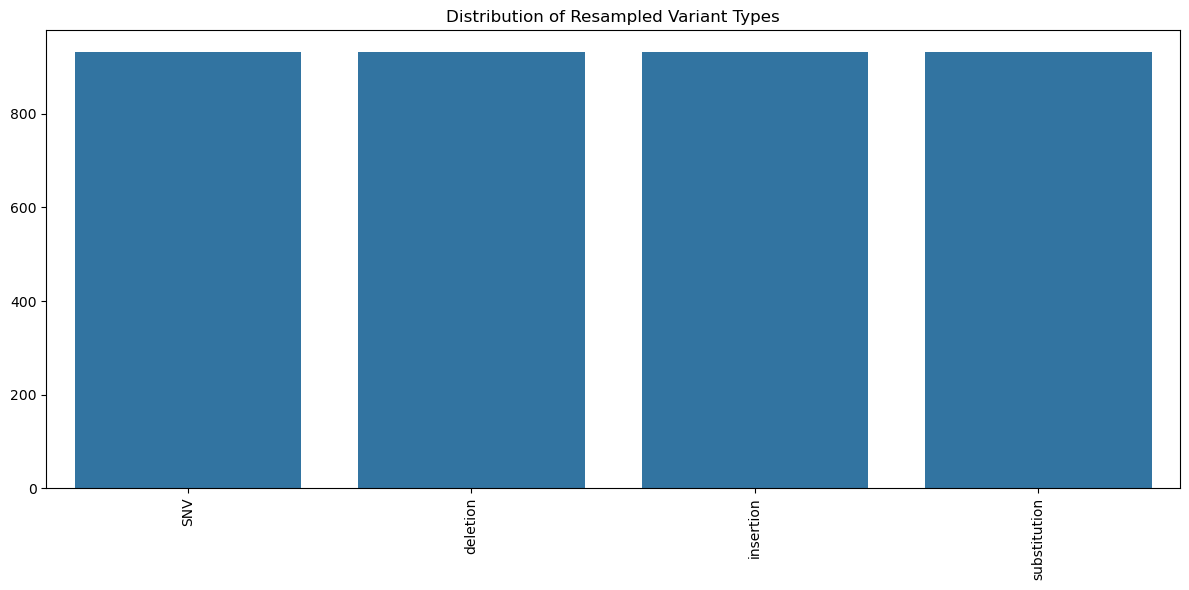

In [116]:
y_val=y_res.value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=['SNV', 'deletion', 'insertion', 'substitution'], y=y_val.values)
plt.xticks(rotation=90)
plt.title("Distribution of Resampled Variant Types")
plt.tight_layout()
plt.show()

Now, the classes are perfectly balanced but I want to check that the classifier won't overfit due to duplicates (perhaps gereated during resampling)

In [117]:
# check for duplicates and count them
duplicates = X_res[X_res.duplicated()]
duplicates_count = duplicates.shape[0]
print(f"Number of duplicates in the resampled data: {duplicates_count}")


Number of duplicates in the resampled data: 153


In [118]:
# take index of duplicates
duplicates_index = duplicates.index
duplicates_index

Index([   9,   36,   40,   41,   50,   51,   63,   75,   87,  101,
       ...
       3303, 3316, 3399, 3503, 3550, 3578, 3586, 3593, 3629, 3643],
      dtype='int64', length=153)

In [119]:
# delete duplicates
X_res = X_res.drop_duplicates()
y_res = y_res.drop(duplicates_index)
print(len(X_res))
len(y_res)

3575


3575

In [120]:
y_res.value_counts()

2    929
1    908
3    908
0    830
Name: count, dtype: int64

After deleting the duplicate rows, we can see that the classes are still balanced.

## **PCA**

### **PCA before SMOTE**

In [121]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3)  
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)


Explained variance ratio: [0.11469922 0.06617839 0.04187325]


/var/folders/r9/tk3nsgjj4_j4z3n_rxsd7s580000gn/T/ipykernel_94516/4259492727.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('viridis', 10))


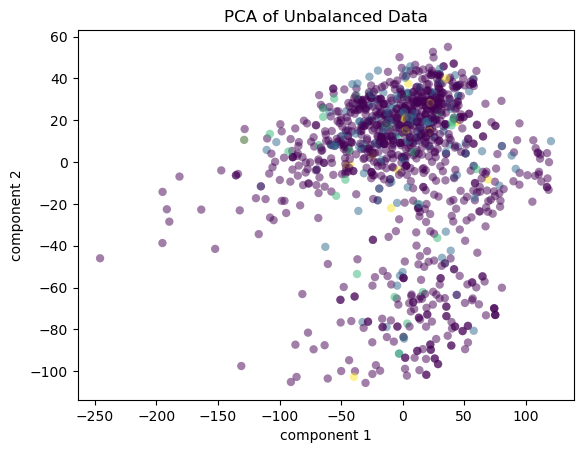

In [122]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('viridis', 10))
plt.xlabel('component 1')
plt.ylabel('component 2')
plt.title('PCA of Unbalanced Data')
plt.show()

/var/folders/r9/tk3nsgjj4_j4z3n_rxsd7s580000gn/T/ipykernel_94516/3125457894.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  ax.scatter3D(x, y1, z, cmap=plt.cm.get_cmap('viridis', 10),c=y, edgecolor='none', alpha=0.5)


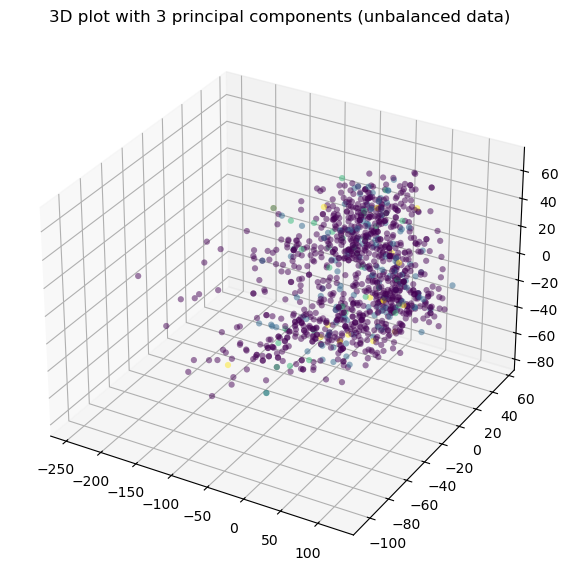

In [123]:
from mpl_toolkits.mplot3d import Axes3D # <--- This is important for 3d plotting

x=X_pca[:, 0]
y1=X_pca[:, 1]
z=X_pca[:, 2]
fig= plt.figure(figsize= (10, 7))
ax = plt.axes(projection="3d")
# Creating plot
ax.scatter3D(x, y1, z, cmap=plt.cm.get_cmap('viridis', 10),c=y, edgecolor='none', alpha=0.5)
plt.title("3D plot with 3 principal components (unbalanced data)")
# show plotfrom mpl_toolkits.mplot3d import Axes3D # <--- This is important for 3d plotting
plt.show()


### **PCA after SMOTE**

In [38]:
scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)

pca = PCA(n_components=3)  
X_pca = pca.fit_transform(X_res_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)


Explained variance ratio: [0.11137742 0.07283252 0.05915741]


/var/folders/r9/tk3nsgjj4_j4z3n_rxsd7s580000gn/T/ipykernel_94516/673733493.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_res.values, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('viridis', 10))


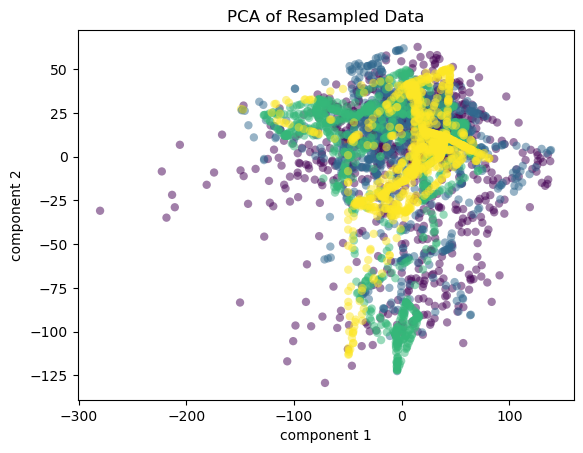

In [39]:

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_res.values, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('viridis', 10))
plt.xlabel('component 1')
plt.ylabel('component 2')
plt.title('PCA of Resampled Data')
# plot legend
legend_elements = [mpatches.Patch(color=plt.cm.viridis(i/10), label=label) for i, label in enumerate(['SNV', 'deletion', 'insertion', 'substitution'])]

/var/folders/r9/tk3nsgjj4_j4z3n_rxsd7s580000gn/T/ipykernel_94516/2639690087.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  ax.scatter3D(x, y, z, cmap=plt.cm.get_cmap('viridis', 10),c=y_res.values, edgecolor='none', alpha=0.5)


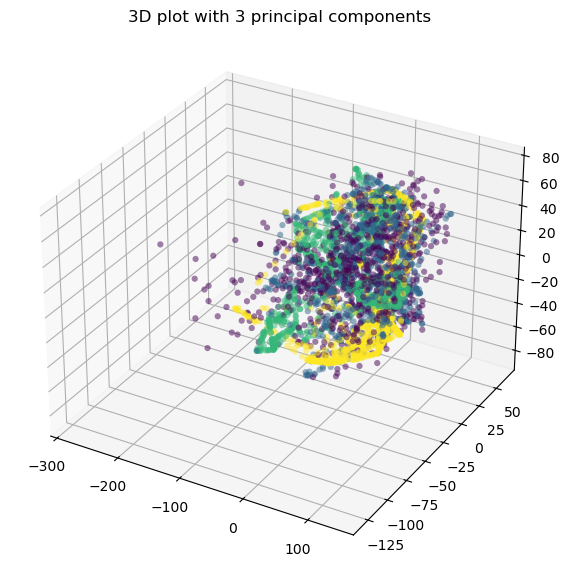

In [ ]:

#### TBD da saltare per ora
# Creating figureax = plt.axes(projection ="3d")
from mpl_toolkits.mplot3d import Axes3D # <--- This is important for 3d plotting

x=X_pca[:, 0]
y=X_pca[:, 1]
z=X_pca[:, 2]
fig= plt.figure(figsize= (10, 7))
ax = plt.axes(projection="3d")
# Creating plot
ax.scatter3D(x, y, z, cmap=plt.cm.get_cmap('viridis', 10),c=y_res.values, edgecolor='none', alpha=0.5)
plt.title("3D plot with 3 principal components")
# show plotfrom mpl_toolkits.mplot3d import Axes3D # <--- This is important for 3d plotting
plt.show()


/var/folders/r9/tk3nsgjj4_j4z3n_rxsd7s580000gn/T/ipykernel_94516/2639690087.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  ax.scatter3D(x, y, z, cmap=plt.cm.get_cmap('viridis', 10),c=y_res.values, edgecolor='none', alpha=0.5)


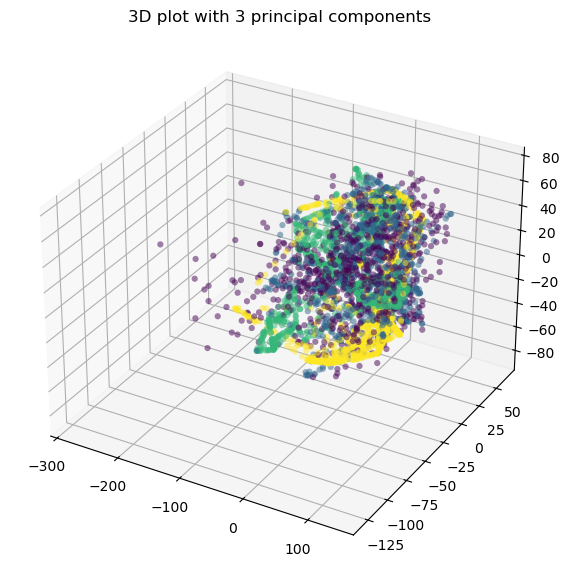

In [40]:

#### TBD da saltare per ora
# Creating figureax = plt.axes(projection ="3d")
from mpl_toolkits.mplot3d import Axes3D # <--- This is important for 3d plotting

x=X_pca[:, 0]
y=X_pca[:, 1]
z=X_pca[:, 2]
fig= plt.figure(figsize= (10, 7))
ax = plt.axes(projection="3d")
# Creating plot
ax.scatter3D(x, y, z, cmap=plt.cm.get_cmap('viridis', 10),c=y_res.values, edgecolor='none', alpha=0.5)
plt.title("3D plot with 3 principal components")
# show plotfrom mpl_toolkits.mplot3d import Axes3D # <--- This is important for 3d plotting
plt.show()


Text(0, 0.5, 'cumulative explained variance')

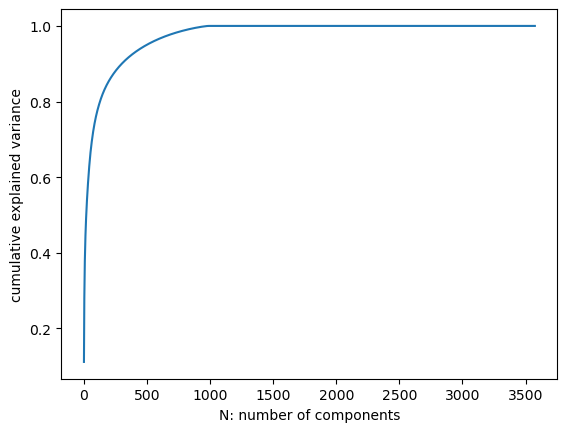

In [41]:
import numpy as np 
pca = PCA().fit(X_res_scaled) # PCA() e' default per tutte le componenti
plt.plot(np.cumsum(pca.explained_variance_ratio_)) # sulle varianze normalizzate al totale
plt.xlabel('N: number of components')
plt.ylabel('cumulative explained variance')

In [42]:
feature_names = X_res.columns
pca = PCA(n_components=3).fit(X_res_scaled)
components = pca.components_

n_top = 10  # Top 10 features
for i, comp in enumerate(components):
    top_indices = np.argsort(np.abs(comp))[::-1][:n_top]
    top_features = feature_names[top_indices]
    top_weights = comp[top_indices]
    
    print(f"\nTop {n_top} features for PC{i+1}:")
    for feat, weight in zip(top_features, top_weights):
        print(f"{feat}: {weight:.4f}")



Top 10 features for PC1:
TARDBP (23435): 0.0182
IP6K1 (9807): 0.0178
KPNB1 (3837): 0.0177
TXLNA (200081): 0.0176
CLSPN (63967): 0.0176
NR2C2 (7182): 0.0175
DDX46 (9879): 0.0175
AGO1 (26523): 0.0175
THRAP3 (9967): 0.0174
RANBP3 (8498): 0.0174

Top 10 features for PC2:
NIBAN2 (64855): 0.0229
CTTN (2017): 0.0229
BCAR1 (9564): 0.0228
AMOTL2 (51421): 0.0227
AGRN (375790): 0.0227
GIPC1 (10755): 0.0227
TJP1 (7082): 0.0224
CTNND1 (1500): 0.0224
PTPRK (5796): 0.0224
SDC4 (6385): 0.0222

Top 10 features for PC3:
CAMSAP3 (57662): 0.0234
PTPN6 (5777): 0.0225
SRPX (8406): -0.0224
OSTM1 (28962): -0.0224
IKBIP (121457): -0.0223
DENND1C (79958): 0.0222
SPARC (6678): -0.0222
TSEN54 (283989): 0.0222
BNC2 (54796): -0.0220
BSPRY (54836): 0.0219


## **Clustering**

In [43]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, adjusted_rand_score, silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linear_sum_assignment



In [44]:

y_true = y_res
class_names = ['SNV', 'deletion', 'insertion', 'substitution']
# Standardize the data (important for k-means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_res)



Confusion Matrix (after optimal mapping):
[[118 290 186 236]
 [ 72 350 171 315]
 [202 195 336 196]
 [ 40 183  58 627]]

Accuracy: 0.4003
Adjusted Rand Index: 0.0731
Silhouette Score: 0.0832

Cluster to class mapping: {3: 0, 0: 1, 1: 2, 2: 3}

PCA explained variance (first 2 components): [0.11137742 0.07283252]
Total PCA explained variance: 65.54%


/var/folders/r9/tk3nsgjj4_j4z3n_rxsd7s580000gn/T/ipykernel_94516/620388584.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab10', n_classes)


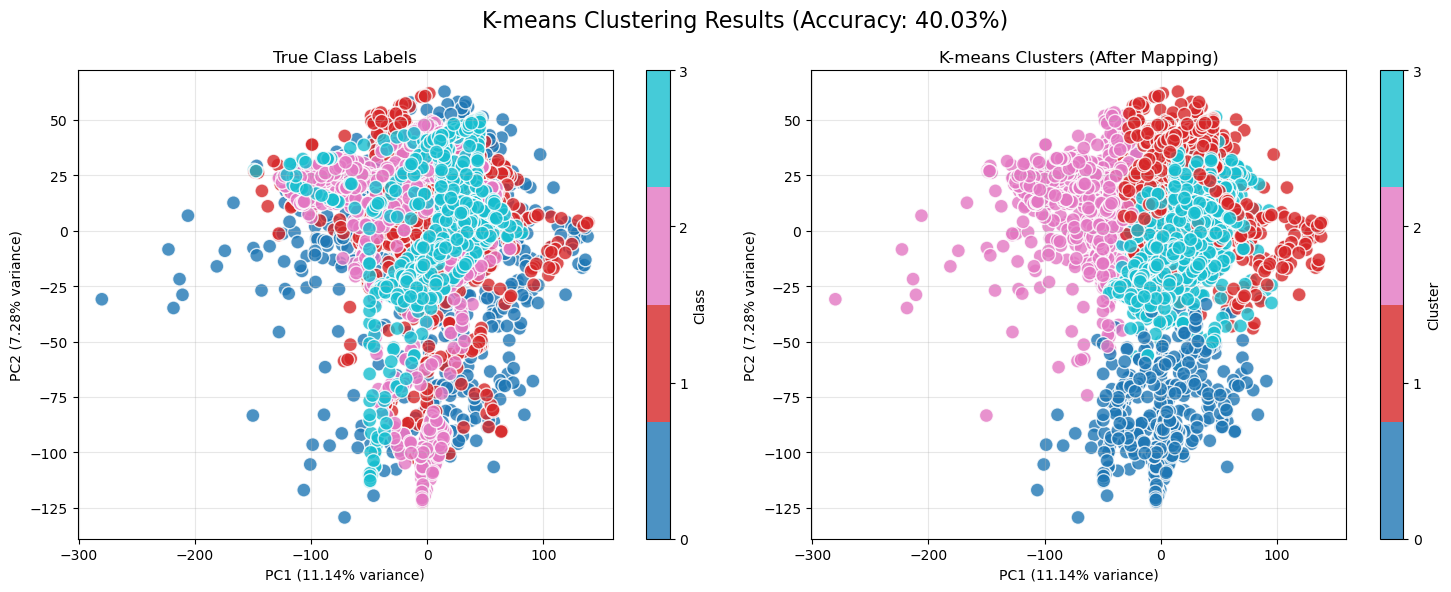

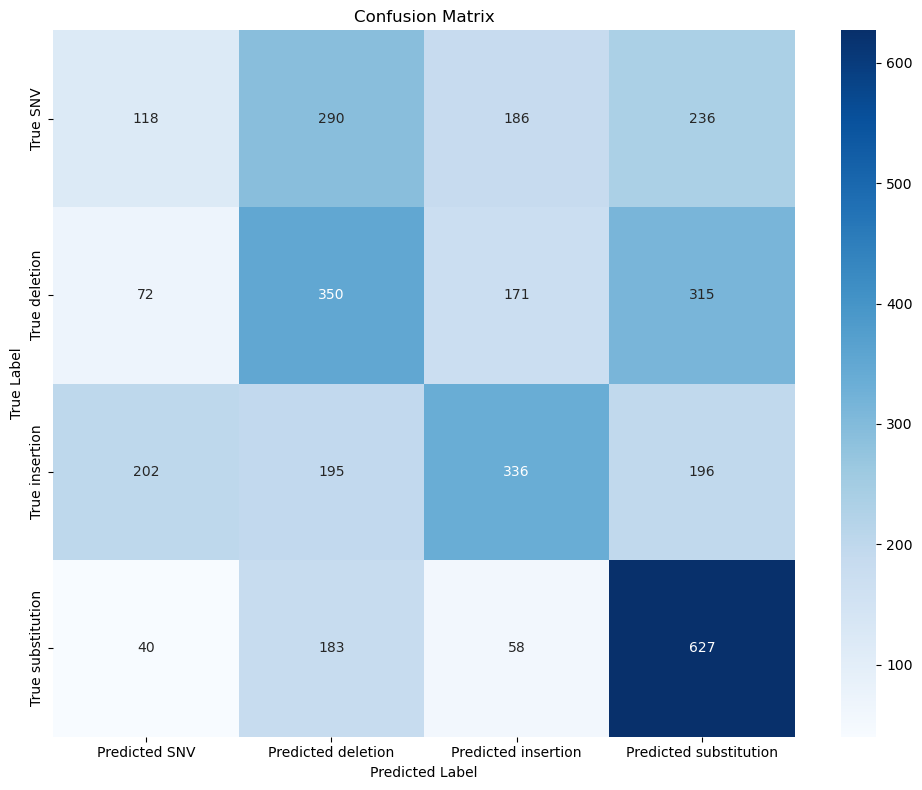


Cross-tabulation of true classes vs. predicted clusters:
Predicted Cluster    0    1    2    3
True Class                           
0                  103  300  173  254
1                   94  322  204  288
2                  180  197  292  260
3                   30  156   48  526


In [45]:

# Apply k-means clustering with the same number of clusters as classes
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X_scaled)
n_classes = 4
# Function to find optimal mapping between clusters and true classes
def find_best_mapping(y_true, y_pred, n_classes):
    """
    Find the optimal mapping between cluster labels and true class labels
    using the Hungarian algorithm to maximize accuracy.
    """
    cm = confusion_matrix(y_true, y_pred)
    # Negate to convert maximization problem to minimization for linear_sum_assignment
    row_ind, col_ind = linear_sum_assignment(-cm)
    
    # Create the mapping
    mapping = {old: new for old, new in zip(col_ind, row_ind)}
    
    # Apply the mapping
    y_pred_mapped = np.array([mapping[p] for p in y_pred])
    
    return y_pred_mapped, mapping

# Find optimal cluster-to-class mapping
y_pred_mapped, cluster_mapping = find_best_mapping(y_true, y_pred, n_classes)

# Evaluate clustering with optimal mapping
accuracy = accuracy_score(y_true, y_pred_mapped)
ari = adjusted_rand_score(y_true, y_pred)
silhouette = silhouette_score(X_scaled, y_pred)

# Create and display confusion matrix
cm = confusion_matrix(y_true, y_pred_mapped)
print("\nConfusion Matrix (after optimal mapping):")
print(cm)

# Calculate and display metrics
print(f"\nAccuracy: {accuracy:.4f}")
print(f"Adjusted Rand Index: {ari:.4f}")
print(f"Silhouette Score: {silhouette:.4f}")
print(f"\nCluster to class mapping: {cluster_mapping}")

# Dimensionality reduction for visualization
# Use PCA first to reduce dimensionality
n_components = min(50, X_scaled.shape[1])  # Avoid using too many components
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)
print(f"\nPCA explained variance (first 2 components): {pca.explained_variance_ratio_[:2]}")
print(f"Total PCA explained variance: {sum(pca.explained_variance_ratio_):.2%}")


# Create a color map for visualization
cmap = plt.cm.get_cmap('tab10', n_classes)

# Visualize results (PCA)
plt.figure(figsize=(15, 6))

# Plot 1: True class status
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap=cmap,
                      alpha=0.8, edgecolors='w', s=100)
plt.title('True Class Labels')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.colorbar(scatter, label='Class', ticks=range(n_classes))
plt.grid(alpha=0.3)

# Plot 2: K-means clusters with mapped labels
plt.subplot(1, 2, 2)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred_mapped, cmap=cmap,
                      alpha=0.8, edgecolors='w', s=100)
plt.title('K-means Clusters (After Mapping)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.colorbar(scatter, label='Cluster', ticks=range(n_classes))
plt.grid(alpha=0.3)

plt.suptitle(f'K-means Clustering Results (Accuracy: {accuracy:.2%})', fontsize=16)
plt.tight_layout()
#plt.savefig('pca_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

# Create a heatmap of the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Predicted {class_names[i]}' for i in range(n_classes)],
            yticklabels=[f'True {class_names[i]}' for i in range(n_classes)])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
#plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Create a cross-tabulation of true labels vs. predicted clusters
cross_tab = pd.crosstab(
    pd.Series(y_true, name='True Class'),
    pd.Series(y_pred_mapped, name='Predicted Cluster')
)
print("\nCross-tabulation of true classes vs. predicted clusters:")
print(cross_tab)




## **Classifiers**

In [46]:

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)
# we scale the features anyway because the log2 transformation does not standardize variance across features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
# Import models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, classification_report, roc_auc_score
    
)

this explains difference of OvR and OvO: https://medium.com/@murpanironit/a-comprehensive-guide-to-multiclass-classification-in-machine-learning-c4f893e8161d

We choose 'micro' averaging method because we use rebalanced dataset and in that case: micro-average precision equals micro-average recall and equals accuracy.
https://www.evidentlyai.com/classification-metrics/multi-class-metrics#precision-and-recall-in-multi-class

In [57]:
# Define the models to try
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    #'CatBoost': CatBoostClassifier(random_state=42, verbose=0), --> ci mette troppo a runnare
    'Support Vector Machine': SVC(probability=True, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5), # --> performs poorly wrt the others
    'XGBoost': XGBClassifier(random_state=42),
}

# Create dictionaries to store results
all_predictions = {}
model_metrics = {
    'Accuracy': [],
    'Weighted Precision': [],
    'Weighted Recall': [],
    'Weighted F1 Score': [],
    'Weighted ROC AUC': []
}


model_names = []
confusion_matrices = {}
class_reports = {}


# Train and evaluate each model
for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # Store predictions
    all_predictions[name] = y_pred
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec_micro = precision_score(y_test, y_pred, average='weighted')
    rec_micro = recall_score(y_test, y_pred, average='weighted')
    f1_micro = f1_score(y_test, y_pred, average='weighted')
    
    # Store metrics
    model_names.append(name)
    model_metrics['Accuracy'].append(acc)
    model_metrics['Weighted Precision'].append(prec_micro)
    model_metrics['Weighted Recall'].append(rec_micro)
    model_metrics['Weighted F1 Score'].append(f1_micro)
    
    # Calculate ROC AUC for multi-class (one-vs-rest)
    if n_classes > 2:
        # Get probability scores
        y_proba = model.predict_proba(X_test_scaled)
        
        # Calculate ROC AUC scores
        roc_auc_micro = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
        
        model_metrics['Weighted ROC AUC'].append(roc_auc_micro)
    
    # Store confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices[name] = cm
    
    # Store classification report
    report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
    class_reports[name] = report
    
    # Print metrics
    print(f"Accuracy: {acc:.4f}")
    print(f"Weighted Precision: {prec_micro:.4f}")
    print(f"Weighted Recall: {rec_micro:.4f}")
    print(f"Weighted F1 Score: {f1_micro:.4f}")
    print(f"Weighted ROC AUC: {roc_auc_micro:.4f}")

# Create a DataFrame with all metrics
metrics_df = pd.DataFrame(model_metrics, index=model_names)
#print("\nAll model metrics:")
#print(metrics_df)




Training Logistic Regression...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.9441
Weighted Precision: 0.9472
Weighted Recall: 0.9441
Weighted F1 Score: 0.9421
Weighted ROC AUC: 0.9909

Training Random Forest...
Accuracy: 0.9888
Weighted Precision: 0.9888
Weighted Recall: 0.9888
Weighted F1 Score: 0.9888
Weighted ROC AUC: 0.9988

Training Support Vector Machine...
Accuracy: 0.9944
Weighted Precision: 0.9945
Weighted Recall: 0.9944
Weighted F1 Score: 0.9944
Weighted ROC AUC: 0.9995

Training K-Nearest Neighbors...
Accuracy: 0.7510
Weighted Precision: 0.8138
Weighted Recall: 0.7510
Weighted F1 Score: 0.6606
Weighted ROC AUC: 0.8888

Training XGBoost...
Accuracy: 0.9860
Weighted Precision: 0.9861
Weighted Recall: 0.9860
Weighted F1 Score: 0.9860
Weighted ROC AUC: 0.9994

All model metrics:
                        Accuracy  Weighted Precision  Weighted Recall  \
Logistic Regression     0.944056            0.947167         0.944056   
Random Forest           0.988811            0.988833         0.988811   
Support Vector Machine  0.994406            0.994

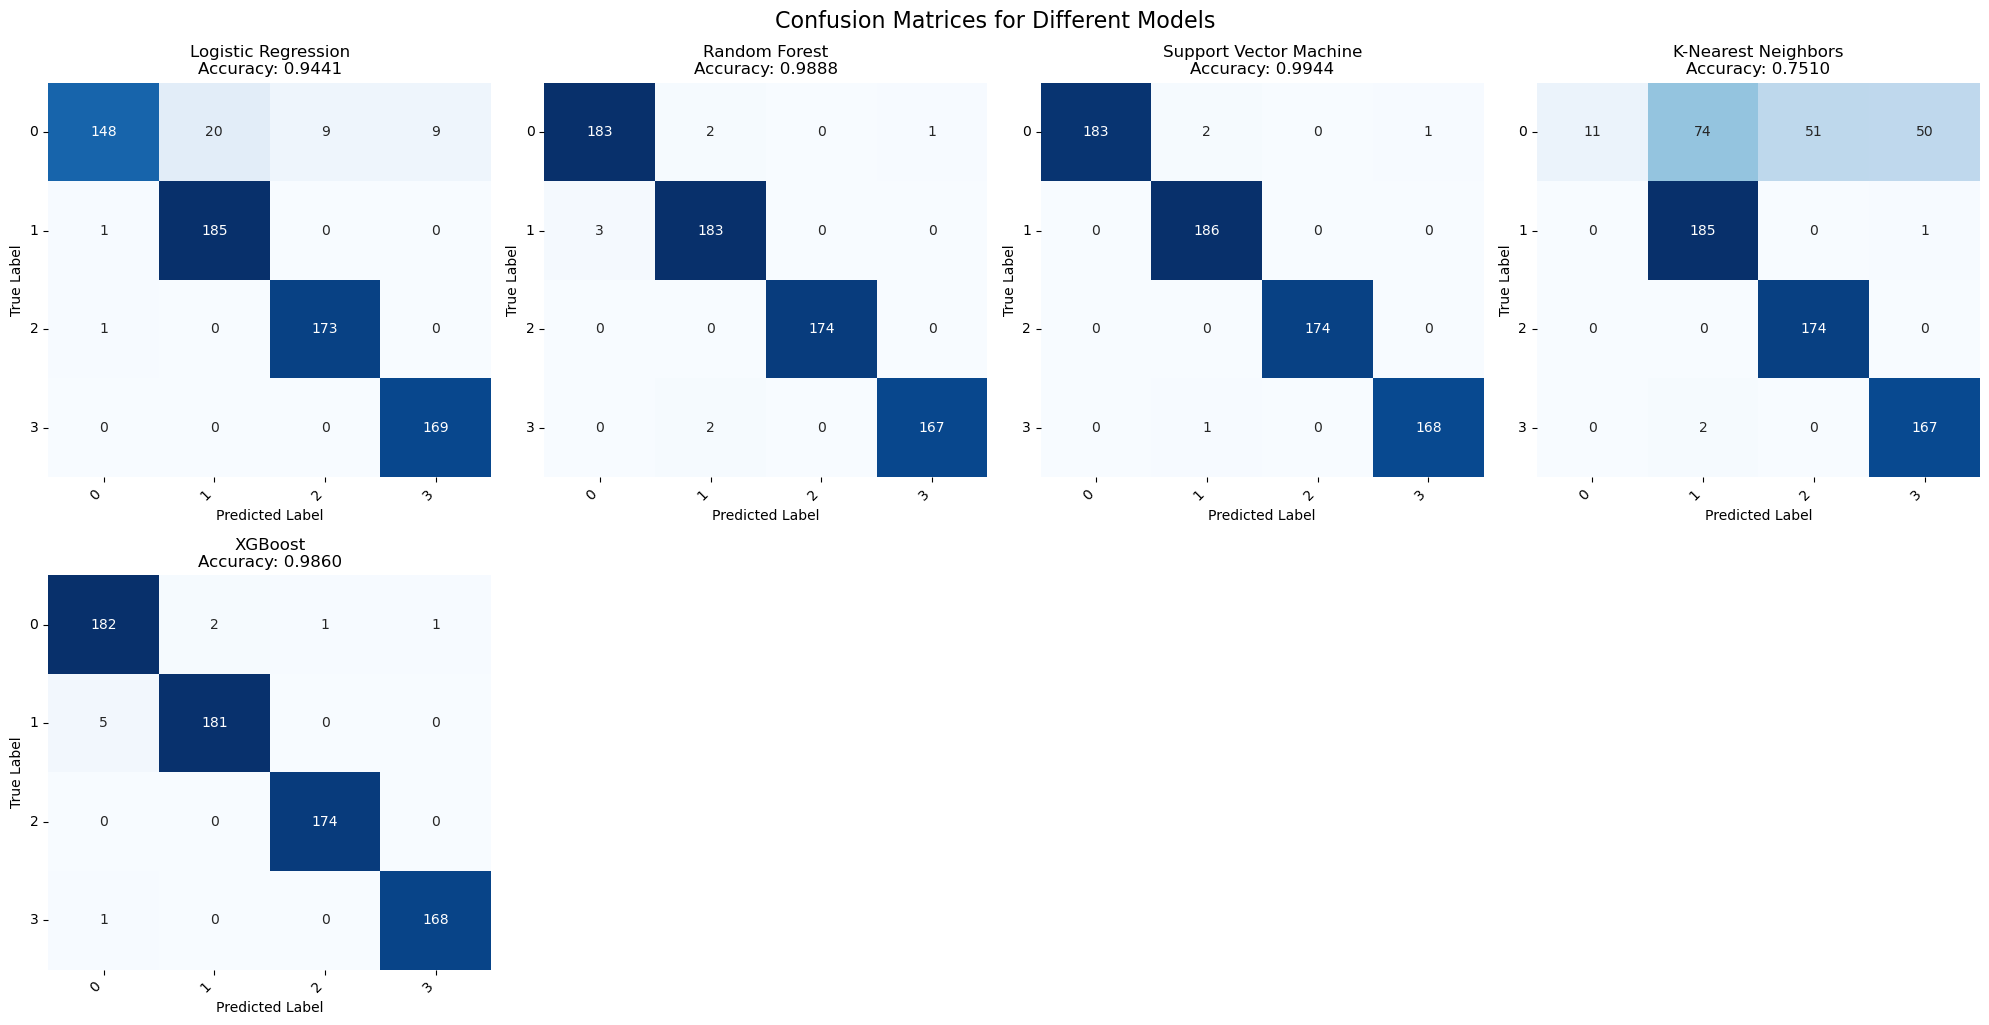

In [58]:
# 1. Plot confusion matrices
n_models = len(models)
rows = (n_models + 3) // 4  # Ceiling division
fig, axes = plt.subplots(rows, 4, figsize=(20, 5 * rows))
axes = axes.flatten()

for i, (name, cm) in enumerate(confusion_matrices.items()):
    if i < len(axes):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i])
        axes[i].set_title(f'{name}\nAccuracy: {model_metrics["Accuracy"][i]:.4f}')
        axes[i].set_xlabel('Predicted Label')
        axes[i].set_ylabel('True Label')
        axes[i].set_xticklabels(class_names, rotation=45, ha='right')
        axes[i].set_yticklabels(class_names, rotation=0)

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle('Confusion Matrices for Different Models', fontsize=16, y=1.02)
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()


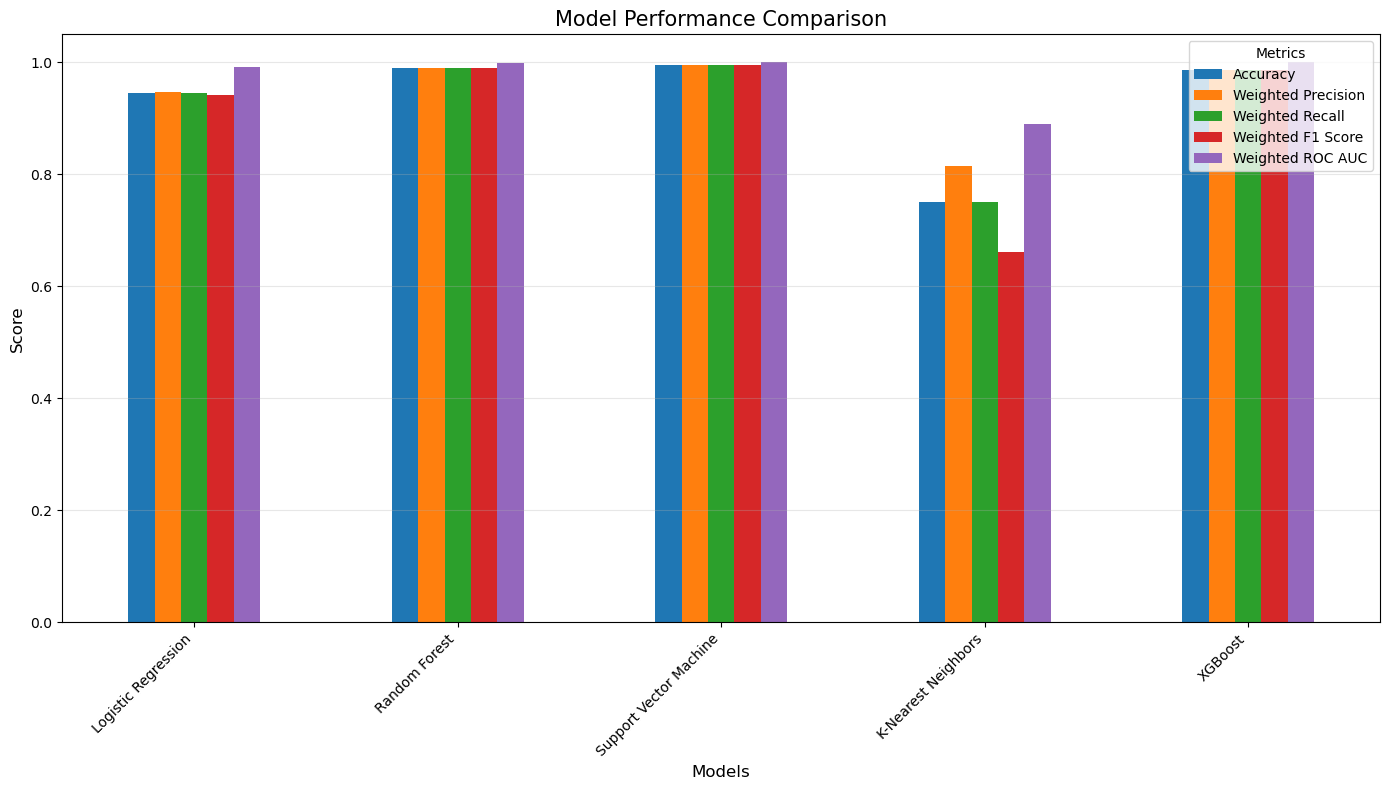

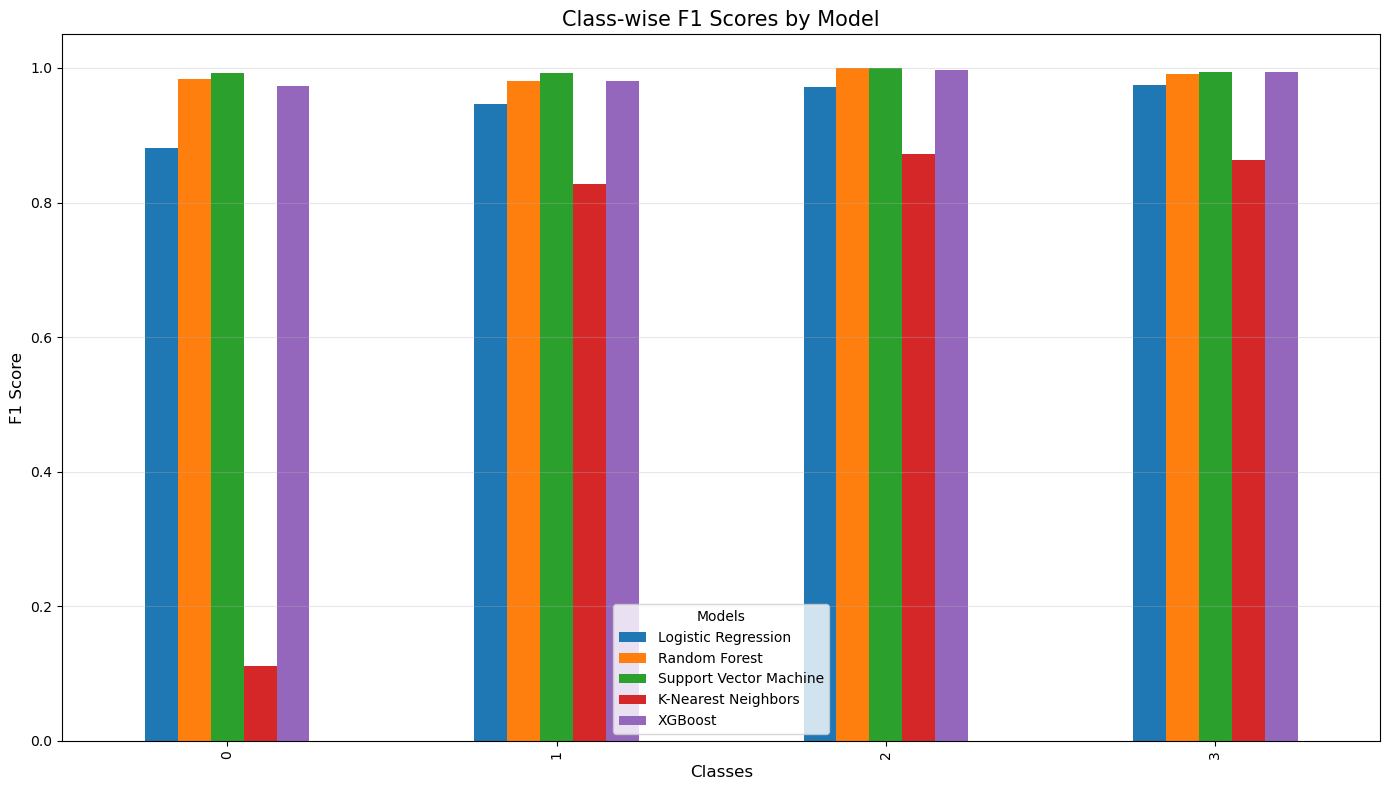

In [60]:

# Plot model performance comparison
metrics_to_plot = list(model_metrics.keys())
metrics_df[metrics_to_plot].plot(kind='bar', figsize=(14, 8))
plt.title('Model Performance Comparison', fontsize=15)
plt.xlabel('Models', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metrics', loc='best')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_performance_comparison.png', dpi=300)
plt.show()


(715,)
(715, 4)


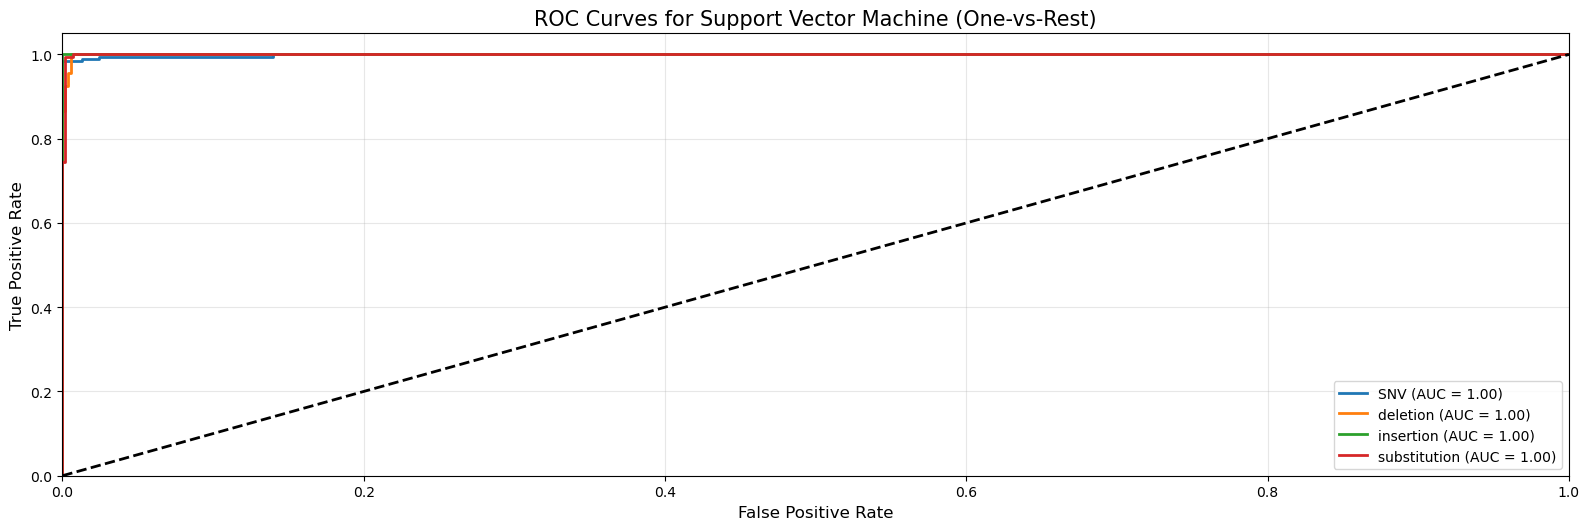

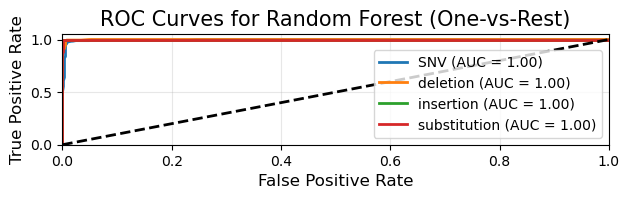

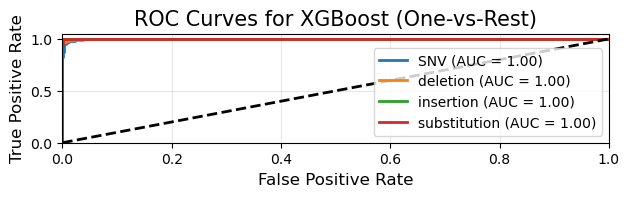

In [68]:
# 4. If number of classes is manageable, plot ROC curves for each class (one-vs-rest)

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize the output for ROC curve calculation
y_test_bin = label_binarize(y_test, classes=np.unique(y_res))
print(y_test.shape)        # should be (n_samples, n_classes)
print(y_test_bin.shape)     # should match


# Plot ROC curves for each class for the top 3 models (based on weighted F1)
top_models = metrics_df.sort_values('Weighted F1 Score', ascending=False).head(3).index

plt.figure(figsize=(16, 5 * len(top_models)))
plot_idx = 1

for model_name in top_models:
    model = models[model_name]
    y_score = model.predict_proba(X_test_scaled)
    
    plt.subplot(len(top_models), 1, plot_idx)
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        #print(f"ROC AUC for {class_names[i]}: {roc_auc:.4f}")
        plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curves for {model_name} (One-vs-Rest)', fontsize=15)
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3)
    
    plot_idx += 1
    
    plt.tight_layout()
    #plt.savefig('roc_curves.png', dpi=300)
    plt.show()

In [62]:
# Find the best model based on different metrics
best_models = {}
for metric in metrics_to_plot:
    best_idx = np.argmax(model_metrics[metric])
    best_models[metric] = model_names[best_idx]

print("\nBest models by metric:")
for metric, model in best_models.items():
    value = metrics_df.loc[model, metric]
    print(f"{metric}: {model} ({value:.4f})")


Best models by metric:
Accuracy: Support Vector Machine (0.9944)
Weighted Precision: Support Vector Machine (0.9945)
Weighted Recall: Support Vector Machine (0.9944)
Weighted F1 Score: Support Vector Machine (0.9944)
Weighted ROC AUC: Support Vector Machine (0.9995)


Given the performance of the different models, the one that emerges is SVM; thus we will perform the next analyses using exclusively that one.

### **Feature Importance**

In [74]:
# Train a linear SVM
final_model = SVC(kernel='linear', probability=True, random_state=42)
final_model.fit(X_train_scaled, y_train)

importances = np.mean(np.abs(final_model.coef_), axis=0)
feature_names = X_train.columns

# Create dataframe and sort
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Display top 10 features
top_10_features = feature_importance_df.sort_values('Importance', ascending=False).head(10)
print("Top 10 Most Important Features (Linear SVM):")
for i, (feature, importance) in enumerate(zip(top_10_features['Feature'], top_10_features['Importance']), 1):
    print(f"{i}. {feature}: {importance:.4f}")



Top 10 Most Important Features (Linear SVM):
1. LRRC72 (100506049): 0.0421
2. FOXB2 (442425): 0.0365
3. PTPRQ (374462): 0.0333
4. NLRP2B (286430): 0.0325
5. SPRR2B (6701): 0.0279
6. SYCN (342898): 0.0263
7. TP53 (7157): 0.0245
8. KRTAP25-1 (100131902): 0.0242
9. MYBPC1 (4604): 0.0227
10. ANKRD60 (140731): 0.0220


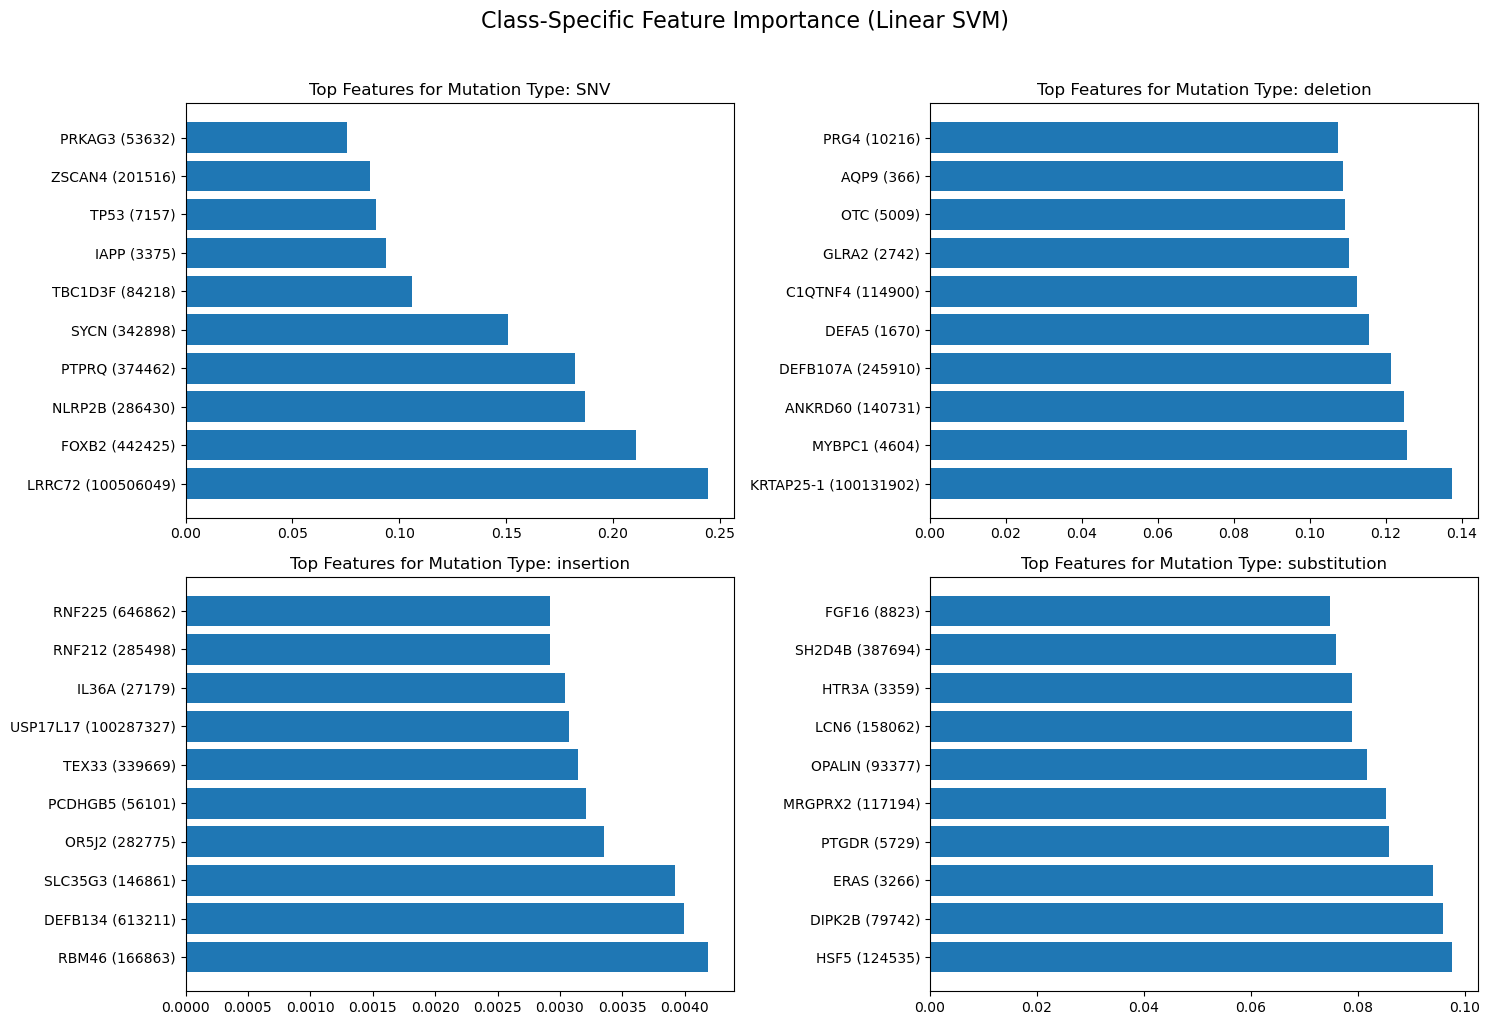

In [75]:
if len(np.unique(y_train)) > 2:
    plt.figure(figsize=(15, 10))
    n_classes = len(np.unique(y_train))
    class_names = {0: 'SNV', 1: 'deletion', 2: 'insertion', 3: 'substitution'}
    for i in range(n_classes):
        plt.subplot(2, (n_classes+1)//2, i+1)
        
        # Get class-specific coefficients
        class_importances = np.abs(final_model.coef_[i])
        class_importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': class_importances
        })
        
        # Get top features for this class
        top_features = class_importance_df.sort_values('Importance', ascending=False).head(10)
        
        # Plot
        plt.barh(range(len(top_features)), top_features['Importance'])
        plt.yticks(range(len(top_features)), top_features['Feature'])
    
        plt.title(f'Top Features for Mutation Type: {class_names[i]}')
        plt.tight_layout()
    
    plt.suptitle('Class-Specific Feature Importance (Linear SVM)', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

## **Step2:** target genes

In [76]:
target_genes = ['CDKN1A', 'ABCA12', 'NTPCR', 'PGPEP1', 'RNF19B', 'LCE1E', 'EPN3', 'SCN4B', 'ARVCF', 'FCHO2', 'PANK2', 'TMEM8B', 'RRM2B', 'ANKRA2', 'ORAI3', 'PLCL2', 'SAC3D1', 'LIMK2', 'FBXO32', 'SCRIB', 'BHLHE40', 'FCHSD2', 'PAQR7', 'TP53', 'MDM2', 'CCNG1', 'PRKAB1', 'PMAIP1', 'SYTL1', 'LRP1', 'FHL2', 'SEMA3B', 'BMP7', 'FLRT2', 'PCBP4', 'TP53I11', 'SUSD6', 'CYFIP2', 'PTP4A1', 'PRDM1', 'TNFRSF10A', 'MCC', 'HES2', 'SLC25A45', 'BORCS7', 'GBE1', 'PERP', 'TRAK1', 'DF15', 'DRAM1', 'SESN2', 'RAP2B', 'TNFRSF10D', 'NUPR1', 'KCNN4', 'SLC44A5', 'BTBD10', 'GPC1', 'PLLP', 'TRIP6', 'BTG2', 'FBXO22', 'SLC30A1', 'RRAD', 'TSPAN11', 'PARD6G', 'KLHDC7A', 'SLC4A11', 'BTG3', 'HES1', 'POU3F1', 'TSGA10 DDB2', 'ISCU', 'SPATA18', 'ZNF219', 'VWCE', 'PHPT1', 'LMNA', 'SLC9A1', 'C17orf89', 'HRAS', 'PPFIBP1', 'UNC5B', 'GADD45A', 'PHLDA3', 'TGFA', 'ZNF337', 'DDIT4', 'PIDD1', 'MLF2', 'STAT3', 'CAPN2', 'HSD17B3', 'PPM1J', 'UQCC1', 'PLK3', 'SERPINB5', 'TLR3', 'ACTA2', 'RAD51C', 'PML', 'MR1', 'STK17A', 'CASP6', 'ICOSLG', 'PPP4R3A', 'VDR', 'TIGAR', 'SERTAD1', 'TM7SF3', 'EDN2', 'SERPINE1', 'PTPRE', 'MYO6', 'STX6', 'CATSPERG', 'IGFBP7', 'PTAFR', 'YPEL3', 'RPS27L', 'TRAF4', 'TMEM68', 'ALOX5', 'TNFAIP8', 'PVRL4', 'NEFL', 'TP73', 'CAV1', 'IL1B', 'RALGDS', 'ZNF195', 'TNFRSF10B', 'TRIM22', 'WDR63', 'ARHGEF3', 'TSKU', 'RETSAT', 'NKAIN4', 'TRIM32', 'CCNK', 'ISYNA1', 'RBM38', 'ZNF385A TRIAP1', 'CES2', 'ZNF561', 'CERS5', 'PCNA', 'REV3L', 'PCLO', 'TRIM38', 'CFLAR', 'JAG1', 'RGL1', 'ZNF488', 'ZMAT3', 'CMBL', 'ZNF79', 'DDR1', 'ACYP2', 'RNASE7', 'PDE4C', 'TRIM5', 'CGB7', 'KRT8', 'RGS20', 'BAX', 'FBXW7', 'ASCC3', 'DHRS3', 'APAF1', 'SFN', 'PGAP1', 'TYMSOS', 'CHST14', 'KSR1', 'RHOC', 'PGF', 'HSPA4L', 'ACER2', 'DUSP14', 'APOBEC3H', 'TNFRSF10C', 'PLCXD2', 'AKAP9', 'COBLL1', 'LACC1', 'RPS19', 'POLH', 'KITLG', 'ANXA4', 'E2F7', 'BCL2L1', 'TRIML2', 'PLEKHF1', 'CCDC51', 'CPEB2', 'LPXN', 'SARS', 'PPM1D', 'SLC12A4', 'APOBEC3C', 'EPS8L2', 'BCL6', 'VCAN', 'PLTP', 'CDH8', 'CPSF4', 'LRPAP1', 'SCIN', 'SULF2', 'ATF3', 'ASTN2', 'FAM210B', 'BLCAP', 'ADCK3', 'PLXNB1', 'DUSP11', 'DNAJB2', 'MFAP3L', 'SCN3B', 'XPC', 'BBC3', 'CD82', 'GLS2', 'C17orf82', 'AK3', 'PLXNB2', 'GCC2', 'DOCK8', 'MKNK2', 'SDC4', 'AEN', 'CCDC90B', 'CDIP1', 'GPX1', 'COL7A1', 'ALDH1A3', 'PRKAB2', 'METTL8', 'DUSP5', 'MON2', 'SDPR', 'BLOC1S2', 'DYRK3', 'CPE', 'GRHL3', 'CPEB4', 'BBS2', 'PRKX', 'PPP1R3C', 'DUSP7', 'MRPL49', 'SMAD3', 'FAS', 'EDA2R', 'CSF1', 'HHAT', 'CSNK1G1', 'BTG1', 'PRODH', 'STEAP3', 'EBI3', 'MYBPHL', 'SNX2', 'GPR87', 'EPHA2', 'DCP1B', 'IGDCC4', 'DGKA', 'CEL', 'PTPRU', 'ABHD4', 'EFNB1', 'MYLK', 'SOCS4', 'NINJ1', 'FAM13C', 'ENC1', 'IKBIP', 'FAM49A', 'CLCA2', 'RGMA', 'ABTB2', 'EI24', 'MYOF', 'TAB3', 'PLK2', 'FAM198B', 'FOSL1', 'LAPTM5', 'FAM84B', 'CLDN1', 'RGS16', 'ADGRG1', 'EML2', 'NFKBIA', 'TCAIM', 'PSTPIP2', 'FAM212B', 'FUCA1', 'MAST4', 'GNAI1', 'CLP1', 'RND3', 'AIFM2', 'ENPP2', 'NHLH2', 'TEP1', 'SESN1', 'FDXR', 'IER5', 'MICALL1', 'INPP1', 'CROT', 'RNF144B', 'AMOTL1', 'ETV7', 'NLRP1', 'TET2', 'TP53I3', 'LIF', 'PADI4', 'NOTCH1', 'ITGA3', 'CYP4F3', 'S100A2', 'AMZ2', 'FAM196A', 'NYNRIN', 'TEX9', 'TP53INP1', 'NADSYN1', 'PANK1', 'RABGGTA', 'KRT15', 'DAPK1', 'SCN2A', 'ARC', 'FAM98C', 'P3H2', 'TMEM63B']

In [77]:
X_res_cleaned = X_res.rename(columns=lambda x: x.split('[')[0].split('(')[0].strip())
selected_columns = [col for col in X_res_cleaned.columns if col in target_genes]
X_res_target = X_res_cleaned[selected_columns]
X_res_target

,CFLAR,CROT,ZNF195,ITGA3,SCIN,REV3L,ETV7,SEMA3B,ALOX5,FAS,...,ADGRG1,NYNRIN,SERPINB5,MYBPHL,GPX1,PLCXD2,APOBEC3C,ZNF488,DUSP14,NEFL
0,5.040454,4.274262,3.553361,7.156842,2.100978,3.555816,0.432959,1.646163,0.214125,3.642702,...,6.021035,0.014355,4.638653,0.000000,6.527633,5.350144,3.452859,1.344828,5.105594,5.531069
1,4.683135,3.092546,3.589763,6.735387,0.565597,4.372952,0.275007,5.521679,0.014355,3.106013,...,6.246028,0.263034,0.014355,0.137504,7.392060,0.495695,5.044831,0.333424,5.570159,0.687061
2,5.744430,3.423578,3.707083,7.525208,0.189034,3.263034,0.000000,1.182692,0.238787,3.577731,...,0.505891,0.097611,0.214125,0.000000,6.925406,1.137504,5.015694,0.028569,3.920293,0.084064
3,5.433293,1.867896,4.021480,8.285772,0.097611,2.531069,1.124328,3.842979,1.077243,1.992768,...,6.811471,1.150560,6.048105,0.056584,8.239073,4.040016,4.110196,4.009885,5.059182,0.042644
4,4.058316,2.918386,3.678072,7.067058,2.698218,2.855990,0.263034,1.992768,0.594549,1.333424,...,6.550593,0.014355,5.627607,0.000000,7.037272,4.072963,3.742006,1.438293,5.178316,3.135863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3723,4.557449,2.425836,3.790678,6.821632,2.519067,3.822839,0.042644,2.025621,0.204122,1.227268,...,6.196207,0.103135,0.250246,0.102884,8.600952,0.893017,4.758413,0.119060,4.820299,1.130875
3724,4.517534,2.518388,3.815744,6.593134,2.813436,3.850175,0.042644,2.173516,0.198793,1.247199,...,6.374339,0.099878,0.259656,0.103694,8.626346,0.851439,4.852351,0.114218,4.857493,1.211854
3725,4.883478,2.663022,3.832466,6.820870,0.235603,3.777586,0.342427,6.170252,0.354594,2.352281,...,5.835065,0.072297,0.326006,0.022641,8.094908,0.889961,5.178511,0.067675,4.960209,0.480826
3726,4.251870,3.290202,3.825179,4.806363,0.098102,3.964889,0.277514,0.874264,0.005612,4.541349,...,1.070611,0.492331,1.429360,0.121314,8.457506,0.276096,4.413980,0.816183,4.617355,2.280755


In [85]:
X_train_target, X_test_target, y_train_target, y_test_target = train_test_split(
    X_res_target, y_res, test_size=0.25, random_state=43, stratify=y_res
)

# we scale the features anyway because the log2 transformation does not standardize variance across features
scaler = StandardScaler()
X_train_targ_scaled = scaler.fit_transform(X_train_target)
X_test_targ_scaled = scaler.transform(X_test_target)

In [86]:
final_model.fit(X_train_targ_scaled, y_train_target)

# Evaluate on test set
y_pred_target = final_model.predict(X_test_targ_scaled)
test_accuracy = accuracy_score(y_test_target, y_pred_target)
print(f"Test accuracy: {test_accuracy:.4f}")

Test accuracy: 0.9463


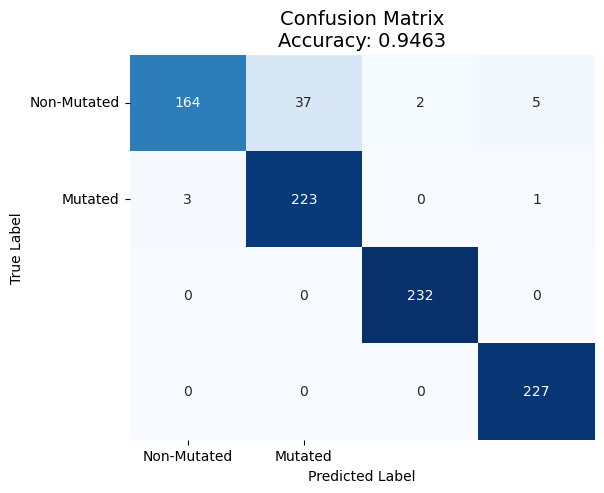

Number of classes: 4


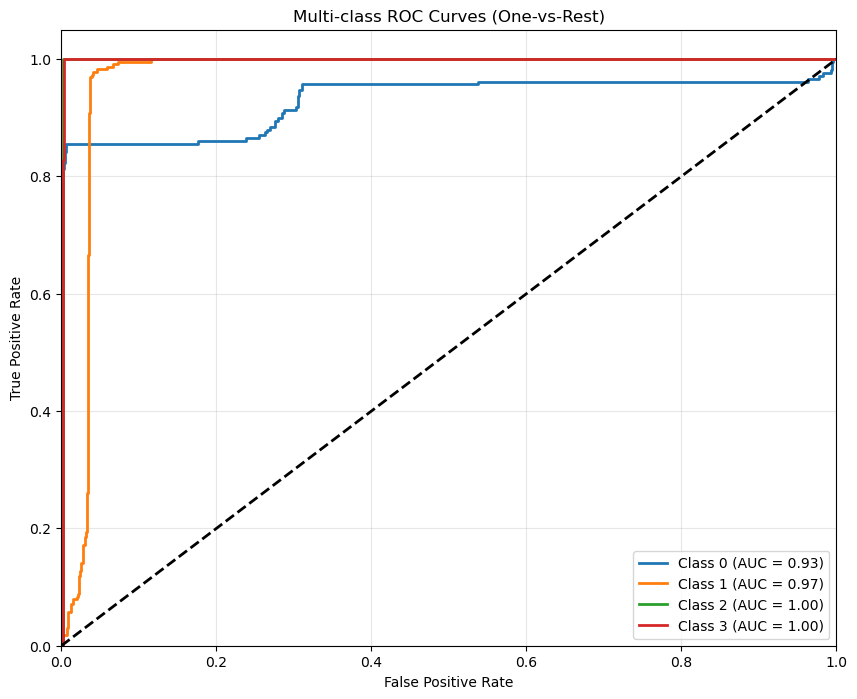

F1 Score: 0.9450
Precision: 0.9509
Recall: 0.9463
ROC AUC: 0.9748

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.79      0.87       208
           1       0.86      0.98      0.92       227
           2       0.99      1.00      1.00       232
           3       0.97      1.00      0.99       227

    accuracy                           0.95       894
   macro avg       0.95      0.94      0.94       894
weighted avg       0.95      0.95      0.95       894



In [95]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    auc
)
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score

# Assuming you already have predictions
cm = confusion_matrix(y_test_target, y_pred_target)
acc = accuracy_score(y_test_target, y_pred_target)

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix\nAccuracy: {acc:.4f}', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks([0.5, 1.5], ['Non-Mutated', 'Mutated'])
plt.yticks([0.5, 1.5], ['Non-Mutated', 'Mutated'], rotation=0)
plt.show()


# Get the number of unique classes
n_classes = len(np.unique(y_test_target))
print(f"Number of classes: {n_classes}")

# Multi-class case - use the full probability matrix
y_pred_prob = final_model.predict_proba(X_test_targ_scaled)

# Multi-class ROC AUC
roc_auc = roc_auc_score(y_test_target, y_pred_prob, multi_class='ovr', average='weighted')

# Multi-class ROC Curves (one per class)
from sklearn.preprocessing import label_binarize

# Binarize the output
classes = np.unique(y_test_target)
y_test_bin = label_binarize(y_test_target, classes=classes)

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    # Calculate ROC curve and ROC area for each class
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc_class = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, 
            label=f'Class {classes[i]} (AUC = {roc_auc_class:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curves (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# Other metrics
f1 = f1_score(y_test_target, y_pred_target, average='weighted')
precision = precision_score(y_test_target, y_pred_target, average='weighted')
recall = recall_score(y_test_target, y_pred_target, average='weighted')

print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

# Full classification report
print("\nClassification Report:")
print(classification_report(y_test_target, y_pred_target))

## **Step3:** Statistically relevant genes

Same classifier but on statistically relevant genes (from differential expression analysis). We import statistically relevant genes from degs csv, we filter df on those and then apply same classifier as before.

In [81]:
degs = pd.read_csv('DEGs_filtered_sorted.csv')
degs = degs.rename(columns={'Unnamed: 0': 'ModelID'})
degs = degs.set_index('ModelID')

In [82]:
X_res_genes= X_res[X_res.columns.intersection(degs.index)]

Test accuracy: 0.9295


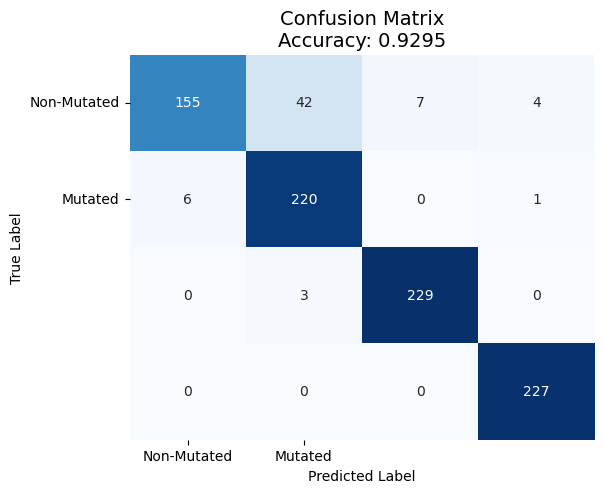

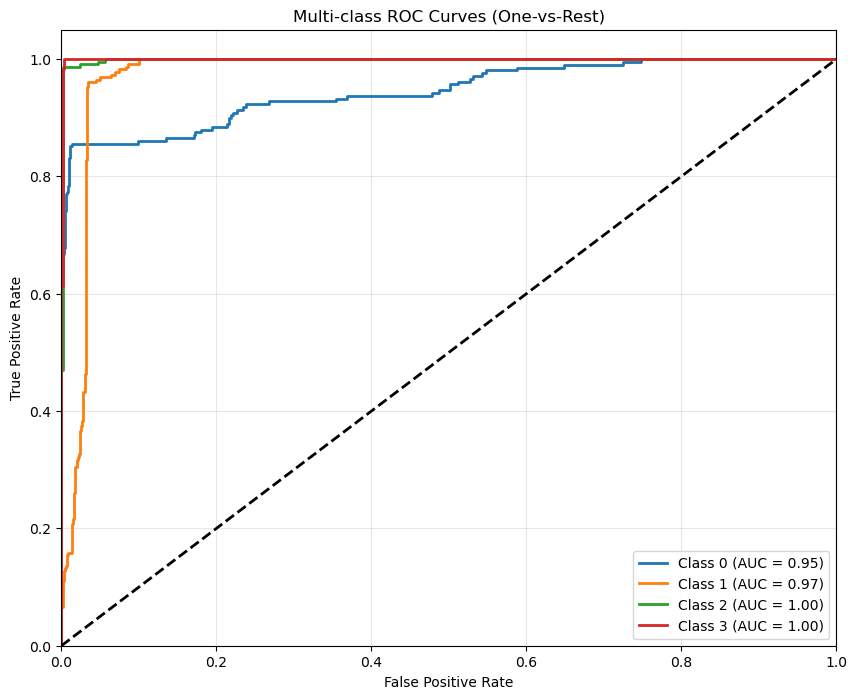

F1 Score: 0.9277
Precision: 0.9350
Recall: 0.9295
ROC AUC: 0.9803

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.75      0.84       208
           1       0.83      0.97      0.89       227
           2       0.97      0.99      0.98       232
           3       0.98      1.00      0.99       227

    accuracy                           0.93       894
   macro avg       0.94      0.93      0.93       894
weighted avg       0.94      0.93      0.93       894



In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res_genes, y_res, test_size=0.25, random_state=43, stratify=y_res
)

# we scale the features anyway because the log2 transformation does not standardize variance across features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
final_model.fit(X_train_scaled, y_train)

y_pred = final_model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_accuracy:.4f}")
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
)
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score

# Assuming you already have predictions
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix\nAccuracy: {acc:.4f}', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks([0.5, 1.5], ['Non-Mutated', 'Mutated'])
plt.yticks([0.5, 1.5], ['Non-Mutated', 'Mutated'], rotation=0)
plt.show()


y_pred_prob = final_model.predict_proba(X_test_scaled)  # For ROC AUC

# Multi-class ROC AUC
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr', average='weighted')

# Multi-class ROC Curves (one per class)
from sklearn.preprocessing import label_binarize

# Binarize the output
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    # Calculate ROC curve and ROC area for each class
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc_class = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, 
            label=f'Class {classes[i]} (AUC = {roc_auc_class:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curves (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# Other metrics
f1 = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test_target, y_pred, average='weighted')
recall = recall_score(y_test_target, y_pred, average='weighted')

print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

# Full classification report
print("\nClassification Report:")
print(classification_report(y_test_target, y_pred))